# Algorithm Analysis and Simulation Toolkit
**Final Project — Algorithms & Complexity | Term 2, SY 2025–2026**

---
### Contents
1. [Part 1 — Sorting Algorithm Comparison](#part1)
2. [Part 2 — MST: Kruskal's & Prim's](#part2)
3. [Part 3 — Recursive Function Simulation](#part3)

In [1]:
# Core imports used throughout the notebook
import time
import random
import copy
import math
import heapq
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np
from collections import defaultdict
from IPython.display import display
import pandas as pd

# Consistent plot style
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'monospace'

print('All imports loaded successfully.')

All imports loaded successfully.


---
<a id='part1'></a>
## Part 1 — Sorting Algorithm Comparison

Implements all 8 algorithms from the spec. Each returns `(sorted_list, comparisons, swaps)` so we can compare them side by side on identical datasets.

In [2]:
# ── BUBBLE SORT ──────────────────────────────────────────────────────────────
def bubble_sort(arr):
    a = arr[:]
    n = len(a)
    comps = swaps = 0
    for i in range(n):
        swapped = False
        for j in range(0, n - i - 1):
            comps += 1
            if a[j] > a[j + 1]:
                a[j], a[j + 1] = a[j + 1], a[j]
                swaps += 1
                swapped = True
        if not swapped:   # already sorted — early exit
            break
    return a, comps, swaps


# ── SELECTION SORT ───────────────────────────────────────────────────────────
def selection_sort(arr):
    a = arr[:]
    n = len(a)
    comps = swaps = 0
    for i in range(n):
        min_idx = i
        for j in range(i + 1, n):
            comps += 1
            if a[j] < a[min_idx]:
                min_idx = j
        if min_idx != i:
            a[i], a[min_idx] = a[min_idx], a[i]
            swaps += 1
    return a, comps, swaps


# ── INSERTION SORT ───────────────────────────────────────────────────────────
def insertion_sort(arr):
    a = arr[:]
    comps = swaps = 0
    for i in range(1, len(a)):
        key = a[i]
        j = i - 1
        while j >= 0:
            comps += 1
            if a[j] > key:
                a[j + 1] = a[j]
                swaps += 1
                j -= 1
            else:
                break
        a[j + 1] = key
    return a, comps, swaps


# ── MERGE SORT ───────────────────────────────────────────────────────────────
def merge_sort(arr):
    comps_ref = [0]

    def _merge(left, right):
        result = []
        i = j = 0
        while i < len(left) and j < len(right):
            comps_ref[0] += 1
            if left[i] <= right[j]:
                result.append(left[i]); i += 1
            else:
                result.append(right[j]); j += 1
        result.extend(left[i:])
        result.extend(right[j:])
        return result

    def _sort(a):
        if len(a) <= 1:
            return a
        mid = len(a) // 2
        return _merge(_sort(a[:mid]), _sort(a[mid:]))

    sorted_arr = _sort(arr[:])
    return sorted_arr, comps_ref[0], 0   # merge sort has no in-place swaps


# ── QUICK SORT (deterministic — last element pivot) ──────────────────────────
def quick_sort(arr):
    comps_ref = [0]
    swaps_ref = [0]

    def _partition(a, lo, hi):
        pivot = a[hi]
        i = lo - 1
        for j in range(lo, hi):
            comps_ref[0] += 1
            if a[j] <= pivot:
                i += 1
                a[i], a[j] = a[j], a[i]
                swaps_ref[0] += 1
        a[i + 1], a[hi] = a[hi], a[i + 1]
        swaps_ref[0] += 1
        return i + 1

    def _sort(a, lo, hi):
        if lo < hi:
            p = _partition(a, lo, hi)
            _sort(a, lo, p - 1)
            _sort(a, p + 1, hi)

    a = arr[:]
    _sort(a, 0, len(a) - 1)
    return a, comps_ref[0], swaps_ref[0]


# ── RANDOMIZED QUICK SORT ────────────────────────────────────────────────────
def random_quick_sort(arr):
    comps_ref = [0]
    swaps_ref = [0]

    def _partition(a, lo, hi):
        rand_idx = random.randint(lo, hi)          # random pivot choice
        a[rand_idx], a[hi] = a[hi], a[rand_idx]
        swaps_ref[0] += 1
        pivot = a[hi]
        i = lo - 1
        for j in range(lo, hi):
            comps_ref[0] += 1
            if a[j] <= pivot:
                i += 1
                a[i], a[j] = a[j], a[i]
                swaps_ref[0] += 1
        a[i + 1], a[hi] = a[hi], a[i + 1]
        swaps_ref[0] += 1
        return i + 1

    def _sort(a, lo, hi):
        if lo < hi:
            p = _partition(a, lo, hi)
            _sort(a, lo, p - 1)
            _sort(a, p + 1, hi)

    a = arr[:]
    _sort(a, 0, len(a) - 1)
    return a, comps_ref[0], swaps_ref[0]


# ── COUNTING SORT ────────────────────────────────────────────────────────────
def counting_sort(arr):
    """Works on non-negative integers. Comparisons counted during count phase."""
    if not arr:
        return [], 0, 0
    a = arr[:]
    max_val = max(a)
    count = [0] * (max_val + 1)
    comps = 0
    for val in a:
        count[val] += 1
        comps += 1   # each placement is a 'comparison' with the index
    result = []
    for i, c in enumerate(count):
        result.extend([i] * c)
    return result, comps, 0  # no swaps — output is built fresh


# ── RADIX SORT (LSD, base-10) ────────────────────────────────────────────────
def radix_sort(arr):
    """LSD radix sort. Comparisons counted per digit pass."""
    if not arr:
        return [], 0, 0
    a = arr[:]
    comps = 0
    max_val = max(a)
    exp = 1
    while max_val // exp > 0:
        buckets = [[] for _ in range(10)]
        for num in a:
            digit = (num // exp) % 10
            buckets[digit].append(num)
            comps += 1
        a = [num for bucket in buckets for num in bucket]
        exp *= 10
    return a, comps, 0


print('All 8 sorting algorithms defined.')

All 8 sorting algorithms defined.


In [3]:
# ── BENCHMARK RUNNER ─────────────────────────────────────────────────────────

ALGORITHMS = {
    'Bubble Sort':         bubble_sort,
    'Selection Sort':      selection_sort,
    'Insertion Sort':      insertion_sort,
    'Merge Sort':          merge_sort,
    'Quick Sort':          quick_sort,
    'Random-Quick Sort':   random_quick_sort,
    'Counting Sort':       counting_sort,
    'Radix Sort':          radix_sort,
}

def benchmark(dataset_size=1000, value_range=(0, 9999), runs=3):
    """Run every algorithm on the same random dataset and collect metrics.
    Averages over `runs` trials to reduce timing noise."""
    dataset = [random.randint(*value_range) for _ in range(dataset_size)]
    results = []

    for name, fn in ALGORITHMS.items():
        times = []
        comps = swaps = 0
        for _ in range(runs):
            start = time.perf_counter()
            _, c, s = fn(dataset)
            elapsed = (time.perf_counter() - start) * 1000   # ms
            times.append(elapsed)
            comps, swaps = c, s
        results.append({
            'Algorithm':   name,
            'Time (ms)':   round(sum(times) / runs, 4),
            'Comparisons': comps,
            'Swaps':       swaps,
        })

    df = pd.DataFrame(results).sort_values('Time (ms)').reset_index(drop=True)
    df.index += 1  # rank starts at 1
    print(f'Dataset Size: {dataset_size}  |  Value Range: {value_range}  |  Runs averaged: {runs}\n')
    display(df)
    return df


results_df = benchmark(dataset_size=1000)

Dataset Size: 1000  |  Value Range: (0, 9999)  |  Runs averaged: 3



,Algorithm,Time (ms),Comparisons,Swaps
1,Radix Sort,0.2214,4000,0
2,Counting Sort,0.4562,1000,0
3,Quick Sort,0.6068,10970,6513
4,Random-Quick Sort,0.6710,10437,6692
5,Merge Sort,0.8398,8732,0
6,Insertion Sort,9.0216,259839,258845
7,Selection Sort,9.2189,499500,988
8,Bubble Sort,19.7657,496014,258845


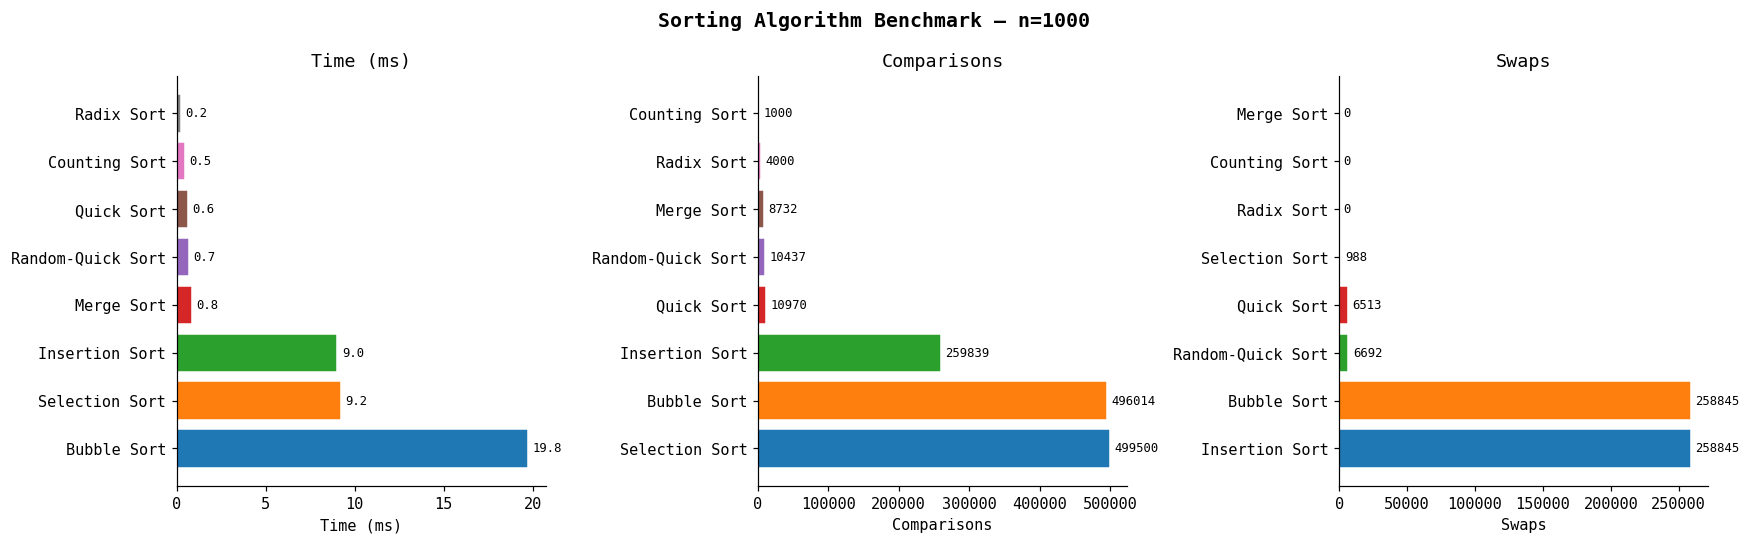

Chart saved.


In [4]:
# ── PERFORMANCE CHART — TIME ──────────────────────────────────────────────────

colors = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Sorting Algorithm Benchmark — n=1000', fontsize=13, fontweight='bold')

metrics = ['Time (ms)', 'Comparisons', 'Swaps']
for ax, metric in zip(axes, metrics):
    sorted_df = results_df.sort_values(metric, ascending=False)
    bars = ax.barh(sorted_df['Algorithm'], sorted_df[metric],
                   color=colors[:len(sorted_df)], edgecolor='white')
    ax.set_xlabel(metric)
    ax.set_title(metric)
    ax.bar_label(bars, fmt='%.1f' if metric == 'Time (ms)' else '%d',
                 padding=3, fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('sorting_benchmark.png', bbox_inches='tight')
plt.show()
print('Chart saved.')

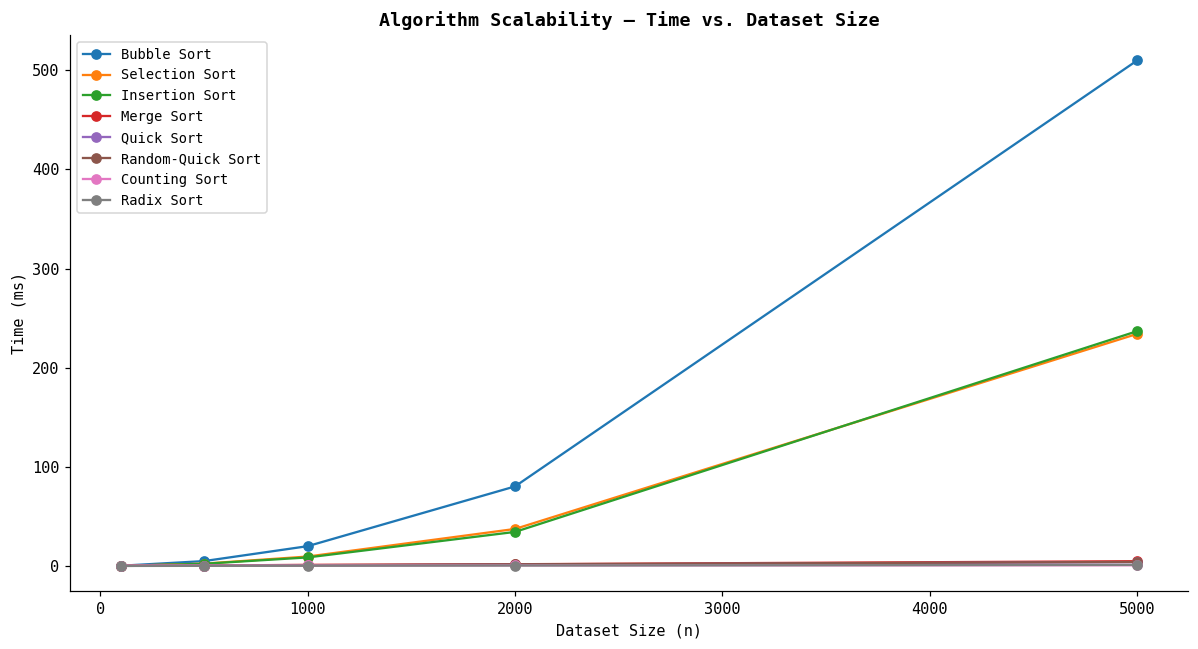

In [5]:
# ── SCALABILITY TEST — multiple dataset sizes ────────────────────────────────
# Shows how each algorithm behaves as n grows.

SIZES = [100, 500, 1000, 2000, 5000]
scale_data = {name: [] for name in ALGORITHMS}

for size in SIZES:
    dataset = [random.randint(0, 9999) for _ in range(size)]
    for name, fn in ALGORITHMS.items():
        start = time.perf_counter()
        fn(dataset)
        scale_data[name].append((time.perf_counter() - start) * 1000)

fig, ax = plt.subplots(figsize=(11, 6))
for i, (name, times) in enumerate(scale_data.items()):
    ax.plot(SIZES, times, marker='o', label=name, color=colors[i])

ax.set_xlabel('Dataset Size (n)')
ax.set_ylabel('Time (ms)')
ax.set_title('Algorithm Scalability — Time vs. Dataset Size', fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('sorting_scalability.png', bbox_inches='tight')
plt.show()

In [6]:
# ── STEP-BY-STEP TRACE — Bubble Sort on small array ──────────────────────────
# Prints each pass so you can see the algorithm progressing.

def bubble_sort_trace(arr, max_steps=20):
    a = arr[:]
    n = len(a)
    step = 0
    print(f'Initial: {a}')
    for i in range(n):
        for j in range(0, n - i - 1):
            if a[j] > a[j + 1]:
                a[j], a[j + 1] = a[j + 1], a[j]
                step += 1
                print(f'  Step {step:3d} | swap index {j} & {j+1}: {a}')
                if step >= max_steps:
                    print('  ... (trace truncated)')
                    return a
    print(f'Sorted:  {a}')
    return a

sample = random.sample(range(1, 30), 10)
print('=== Bubble Sort Step-by-Step Trace ===')
bubble_sort_trace(sample)

=== Bubble Sort Step-by-Step Trace ===
Initial: [24, 5, 20, 17, 18, 22, 1, 27, 21, 10]
  Step   1 | swap index 0 & 1: [5, 24, 20, 17, 18, 22, 1, 27, 21, 10]
  Step   2 | swap index 1 & 2: [5, 20, 24, 17, 18, 22, 1, 27, 21, 10]
  Step   3 | swap index 2 & 3: [5, 20, 17, 24, 18, 22, 1, 27, 21, 10]
  Step   4 | swap index 3 & 4: [5, 20, 17, 18, 24, 22, 1, 27, 21, 10]
  Step   5 | swap index 4 & 5: [5, 20, 17, 18, 22, 24, 1, 27, 21, 10]
  Step   6 | swap index 5 & 6: [5, 20, 17, 18, 22, 1, 24, 27, 21, 10]
  Step   7 | swap index 7 & 8: [5, 20, 17, 18, 22, 1, 24, 21, 27, 10]
  Step   8 | swap index 8 & 9: [5, 20, 17, 18, 22, 1, 24, 21, 10, 27]
  Step   9 | swap index 1 & 2: [5, 17, 20, 18, 22, 1, 24, 21, 10, 27]
  Step  10 | swap index 2 & 3: [5, 17, 18, 20, 22, 1, 24, 21, 10, 27]
  Step  11 | swap index 4 & 5: [5, 17, 18, 20, 1, 22, 24, 21, 10, 27]
  Step  12 | swap index 6 & 7: [5, 17, 18, 20, 1, 22, 21, 24, 10, 27]
  Step  13 | swap index 7 & 8: [5, 17, 18, 20, 1, 22, 21, 10, 24, 27]
  S

[5, 1, 17, 18, 10, 20, 21, 22, 24, 27]

In [7]:
# ── BEST / AVERAGE / WORST CASE ANALYSIS ────────────────────────────────────
# Tests each algorithm on already-sorted, random, and reverse-sorted input.

n = 500
cases = {
    'Best (sorted)':    list(range(n)),
    'Average (random)': random.sample(range(n * 10), n),
    'Worst (reversed)': list(range(n, 0, -1)),
}

case_results = []
for case_name, data in cases.items():
    for alg_name, fn in ALGORITHMS.items():
        start = time.perf_counter()
        _, c, s = fn(data)
        t = (time.perf_counter() - start) * 1000
        case_results.append({'Case': case_name, 'Algorithm': alg_name,
                              'Time (ms)': round(t, 4), 'Comparisons': c})

case_df = pd.DataFrame(case_results)
pivot = case_df.pivot(index='Algorithm', columns='Case', values='Time (ms)')
print(f'Best / Average / Worst Case Times (ms) — n={n}\n')
display(pivot.sort_values('Average (random)'))

Best / Average / Worst Case Times (ms) — n=500



Case,Average (random),Best (sorted),Worst (reversed)
Algorithm,,,
Radix Sort,0.1284,0.0899,0.0870
Counting Sort,0.2325,0.0398,0.0459
Quick Sort,0.2726,6.9106,5.1762
Random-Quick Sort,0.3143,0.2865,0.3085
Merge Sort,0.3803,0.2681,0.2766
Insertion Sort,2.2793,0.0232,4.6408
Selection Sort,2.7935,2.7396,2.4600
Bubble Sort,4.8466,0.0110,5.7424


---
<a id='part2'></a>
## Part 2 — Minimum Spanning Tree: Kruskal's & Prim's

Both algorithms are implemented with full step-by-step tracing and a side-by-side NetworkX visualization.

In [8]:
# ── UNION-FIND (Disjoint Set Union) for Kruskal's ────────────────────────────
class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank   = [0] * n

    def find(self, x):
        # path compression
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, x, y):
        rx, ry = self.find(x), self.find(y)
        if rx == ry:
            return False   # cycle detected
        # union by rank keeps tree flat
        if self.rank[rx] < self.rank[ry]:
            rx, ry = ry, rx
        self.parent[ry] = rx
        if self.rank[rx] == self.rank[ry]:
            self.rank[rx] += 1
        return True


# ── KRUSKAL'S ALGORITHM ──────────────────────────────────────────────────────
def kruskal(vertices, edges, verbose=True):
    """
    vertices : list of vertex labels (0-indexed ints or strings)
    edges    : list of (u, v, weight)
    Returns  : (mst_edges, total_cost)
    """
    n = len(vertices)
    v_index = {v: i for i, v in enumerate(vertices)}   # label → index
    uf = UnionFind(n)
    mst = []

    sorted_edges = sorted(edges, key=lambda e: e[2])   # step 1: sort by weight

    if verbose:
        print('=== KRUSKAL\'S ALGORITHM ===')
        print(f'Vertices : {vertices}')
        print(f'Edges sorted by weight:')
        for u, v, w in sorted_edges:
            print(f'  ({u}--{v}, w={w})')
        print()

    step = 0
    for u, v, w in sorted_edges:
        step += 1
        ui, vi = v_index[u], v_index[v]
        if uf.union(ui, vi):
            mst.append((u, v, w))
            action = 'ADDED  ✓'
        else:
            action = 'SKIPPED (cycle)'
        if verbose:
            print(f'Step {step:2d} | Edge ({u}--{v}, w={w}) → {action}')
        if len(mst) == n - 1:   # MST complete
            break

    total_cost = sum(w for _, _, w in mst)
    if verbose:
        print(f'\nMST Edges:')
        for u, v, w in mst:
            print(f'  {u} -- {v}  (weight {w})')
        print(f'Total MST Cost = {total_cost}')

    return mst, total_cost


# ── PRIM'S ALGORITHM ─────────────────────────────────────────────────────────
def prim(vertices, adj, start=None, verbose=True):
    """
    vertices : list of vertex labels
    adj      : dict { u: [(v, weight), ...] }
    start    : starting vertex (defaults to first)
    Returns  : (mst_edges, total_cost)
    """
    if start is None:
        start = vertices[0]

    visited = set()
    mst = []
    # min-heap: (weight, from_vertex, to_vertex)
    heap = [(0, None, start)]

    if verbose:
        print('=== PRIM\'S ALGORITHM ===')
        print(f'Vertices : {vertices}')
        print(f'Starting vertex: {start}\n')

    step = 0
    while heap:
        w, u, v = heapq.heappop(heap)
        if v in visited:
            continue
        visited.add(v)

        if u is not None:   # skip the phantom entry for the start node
            mst.append((u, v, w))
            step += 1
            if verbose:
                print(f'Step {step:2d} | Add edge ({u}--{v}, w={w}) | MST so far: {[(a,b,c) for a,b,c in mst]}')

        for neighbor, weight in adj.get(v, []):
            if neighbor not in visited:
                heapq.heappush(heap, (weight, v, neighbor))

    total_cost = sum(c for _, _, c in mst)
    if verbose:
        print(f'\nMST Edges:')
        for u, v, w in mst:
            print(f'  {u} -- {v}  (weight {w})')
        print(f'Total MST Cost = {total_cost}')

    return mst, total_cost


# ── HELPER — build adjacency list from edge list ─────────────────────────────
def build_adj(edges):
    adj = defaultdict(list)
    for u, v, w in edges:
        adj[u].append((v, w))
        adj[v].append((u, w))   # undirected
    return dict(adj)


print('MST utilities defined.')

MST utilities defined.


In [9]:
# ── SAMPLE GRAPH ─────────────────────────────────────────────────────────────
# Classic 6-vertex weighted undirected graph

VERTICES = [1, 2, 3, 4, 5, 6]
EDGES = [
    (1, 2, 4), (1, 3, 3),
    (2, 3, 5), (2, 4, 6),
    (3, 4, 7), (3, 5, 8),
    (4, 5, 9), (4, 6, 5),
    (5, 6, 6),
]

ADJ = build_adj(EDGES)

k_mst, k_cost = kruskal(VERTICES, EDGES)

=== KRUSKAL'S ALGORITHM ===
Vertices : [1, 2, 3, 4, 5, 6]
Edges sorted by weight:
  (1--3, w=3)
  (1--2, w=4)
  (2--3, w=5)
  (4--6, w=5)
  (2--4, w=6)
  (5--6, w=6)
  (3--4, w=7)
  (3--5, w=8)
  (4--5, w=9)

Step  1 | Edge (1--3, w=3) → ADDED  ✓
Step  2 | Edge (1--2, w=4) → ADDED  ✓
Step  3 | Edge (2--3, w=5) → SKIPPED (cycle)
Step  4 | Edge (4--6, w=5) → ADDED  ✓
Step  5 | Edge (2--4, w=6) → ADDED  ✓
Step  6 | Edge (5--6, w=6) → ADDED  ✓

MST Edges:
  1 -- 3  (weight 3)
  1 -- 2  (weight 4)
  4 -- 6  (weight 5)
  2 -- 4  (weight 6)
  5 -- 6  (weight 6)
Total MST Cost = 24


In [10]:
p_mst, p_cost = prim(VERTICES, ADJ, start=1)

=== PRIM'S ALGORITHM ===
Vertices : [1, 2, 3, 4, 5, 6]
Starting vertex: 1

Step  1 | Add edge (1--3, w=3) | MST so far: [(1, 3, 3)]
Step  2 | Add edge (1--2, w=4) | MST so far: [(1, 3, 3), (1, 2, 4)]
Step  3 | Add edge (2--4, w=6) | MST so far: [(1, 3, 3), (1, 2, 4), (2, 4, 6)]
Step  4 | Add edge (4--6, w=5) | MST so far: [(1, 3, 3), (1, 2, 4), (2, 4, 6), (4, 6, 5)]
Step  5 | Add edge (6--5, w=6) | MST so far: [(1, 3, 3), (1, 2, 4), (2, 4, 6), (4, 6, 5), (6, 5, 6)]

MST Edges:
  1 -- 3  (weight 3)
  1 -- 2  (weight 4)
  2 -- 4  (weight 6)
  4 -- 6  (weight 5)
  6 -- 5  (weight 6)
Total MST Cost = 24


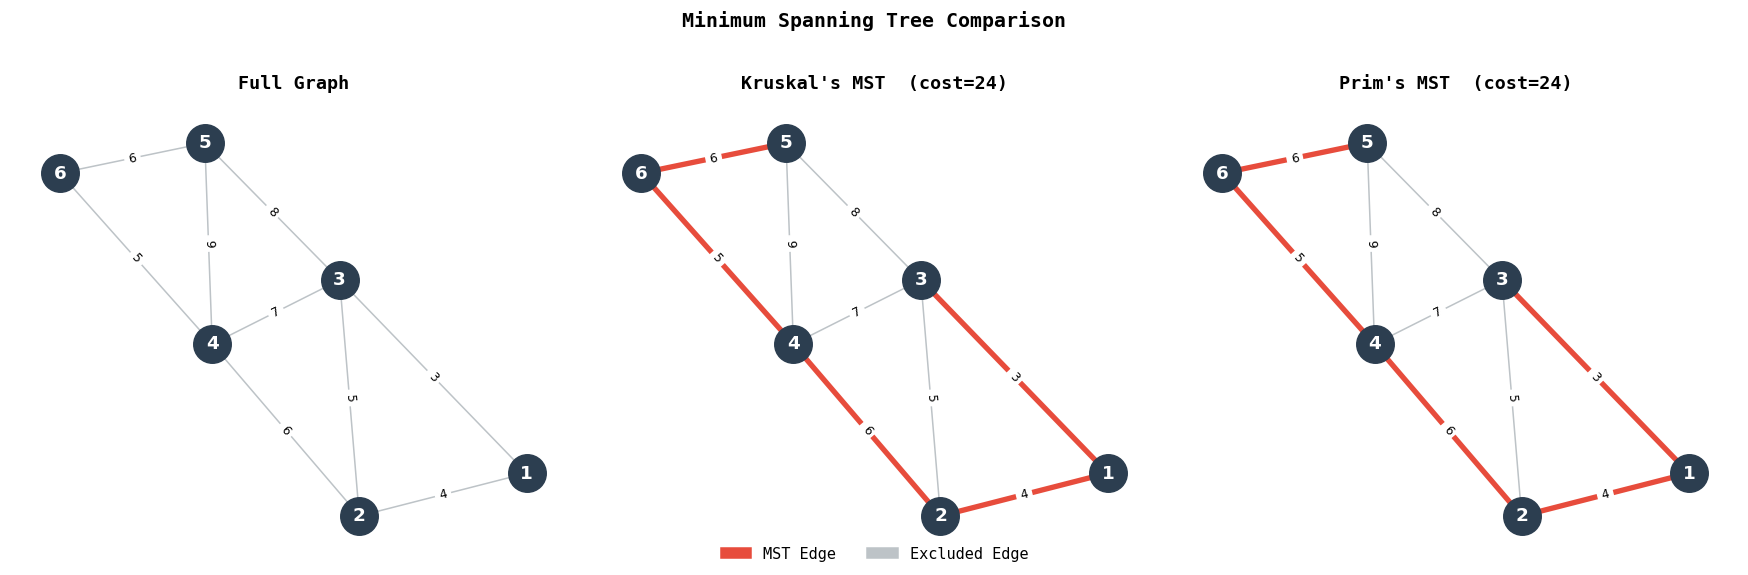


Both algorithms agree on cost: True


In [11]:
# ── GRAPH VISUALIZATION — original + both MSTs ───────────────────────────────

def draw_graph(ax, title, vertices, edges, mst_edges=None):
    G = nx.Graph()
    G.add_nodes_from(vertices)
    for u, v, w in edges:
        G.add_edge(u, v, weight=w)

    pos = nx.spring_layout(G, seed=42)
    mst_set = set()
    if mst_edges:
        mst_set = {(u, v) for u, v, _ in mst_edges} | {(v, u) for u, v, _ in mst_edges}

    edge_colors = ['#e74c3c' if (u, v) in mst_set else '#bdc3c7' for u, v in G.edges()]
    edge_widths = [3.5 if (u, v) in mst_set else 1.0 for u, v in G.edges()]

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color='#2c3e50', node_size=600)
    nx.draw_networkx_labels(G, pos, ax=ax, font_color='white', font_weight='bold')
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors, width=edge_widths)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax, font_size=8)

    ax.set_title(title, fontweight='bold', pad=10)
    ax.axis('off')


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
draw_graph(axes[0], 'Full Graph', VERTICES, EDGES)
draw_graph(axes[1], f"Kruskal's MST  (cost={k_cost})", VERTICES, EDGES, k_mst)
draw_graph(axes[2], f"Prim's MST  (cost={p_cost})", VERTICES, EDGES, p_mst)

red_patch = mpatches.Patch(color='#e74c3c', label='MST Edge')
gray_patch = mpatches.Patch(color='#bdc3c7', label='Excluded Edge')
fig.legend(handles=[red_patch, gray_patch], loc='lower center', ncol=2, frameon=False)

plt.suptitle('Minimum Spanning Tree Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mst_visualization.png', bbox_inches='tight')
plt.show()

print(f'\nBoth algorithms agree on cost: {k_cost == p_cost}')

In [12]:
# ── RANDOM LARGE GRAPH TEST ───────────────────────────────────────────────────
# Stress-test both algorithms on a larger randomly generated graph

def random_graph(n_vertices=15, n_edges=35, weight_range=(1, 50)):
    vertices = list(range(1, n_vertices + 1))
    edge_set = set()
    # Guarantee connectivity by creating a spanning chain first
    for i in range(1, n_vertices):
        w = random.randint(*weight_range)
        edge_set.add((i, i + 1, w))
    while len(edge_set) < n_edges:
        u = random.randint(1, n_vertices)
        v = random.randint(1, n_vertices)
        if u != v:
            w = random.randint(*weight_range)
            edge_set.add((u, v, w))
    return vertices, list(edge_set)


rv, re = random_graph(n_vertices=15, n_edges=40)
ra = build_adj(re)

start_k = time.perf_counter()
km, kc = kruskal(rv, re, verbose=False)
time_k = (time.perf_counter() - start_k) * 1000

start_p = time.perf_counter()
pm, pc = prim(rv, ra, verbose=False)
time_p = (time.perf_counter() - start_p) * 1000

print(f'Random graph — {len(rv)} vertices, {len(re)} edges')
print(f"Kruskal's MST cost : {kc}  ({time_k:.4f} ms)")
print(f"Prim's MST cost    : {pc}  ({time_p:.4f} ms)")
print(f'Costs match        : {kc == pc}')

Random graph — 15 vertices, 40 edges
Kruskal's MST cost : 149  (0.0780 ms)
Prim's MST cost    : 149  (0.0698 ms)
Costs match        : True


---
<a id='part3'></a>
## Part 3 — Recursive Function Simulation

All required recursive functions plus extras, each with call-stack tracing and recursion depth tracking.

In [13]:
# ── INDENTATION HELPER ────────────────────────────────────────────────────────
def indent(depth, symbol='  '):
    return symbol * depth


# ── FACTORIAL ────────────────────────────────────────────────────────────────
def factorial(n, depth=0):
    pad = indent(depth)
    print(f'{pad}factorial({n})')
    if n <= 1:
        print(f'{pad}→ base case: return 1')
        return 1
    result = n * factorial(n - 1, depth + 1)
    print(f'{pad}→ {n} × factorial({n-1}) = {result}')
    return result


print('=== FACTORIAL(6) ===')
ans = factorial(6)
print(f'\nResult = {ans}')

=== FACTORIAL(6) ===
factorial(6)
  factorial(5)
    factorial(4)
      factorial(3)
        factorial(2)
          factorial(1)
          → base case: return 1
        → 2 × factorial(1) = 2
      → 3 × factorial(2) = 6
    → 4 × factorial(3) = 24
  → 5 × factorial(4) = 120
→ 6 × factorial(5) = 720

Result = 720


In [14]:
# ── FIBONACCI ────────────────────────────────────────────────────────────────
# Two versions: naive (exponential) and memoized (linear) — shows the power of
# dynamic programming on recursive problems.

_fib_cache = {}

def fibonacci(n, depth=0, memo=False):
    pad = indent(depth)
    if memo and n in _fib_cache:
        print(f'{pad}fibonacci({n}) → cached: {_fib_cache[n]}')
        return _fib_cache[n]

    print(f'{pad}fibonacci({n})')
    if n <= 1:
        print(f'{pad}→ base case: return {n}')
        return n

    left  = fibonacci(n - 1, depth + 1, memo)
    right = fibonacci(n - 2, depth + 1, memo)
    result = left + right

    if memo:
        _fib_cache[n] = result

    print(f'{pad}→ fib({n-1}) + fib({n-2}) = {left} + {right} = {result}')
    return result


print('=== FIBONACCI(6) — Naive Recursive ===')
ans = fibonacci(6)
print(f'\nResult = {ans}')

=== FIBONACCI(6) — Naive Recursive ===
fibonacci(6)
  fibonacci(5)
    fibonacci(4)
      fibonacci(3)
        fibonacci(2)
          fibonacci(1)
          → base case: return 1
          fibonacci(0)
          → base case: return 0
        → fib(1) + fib(0) = 1 + 0 = 1
        fibonacci(1)
        → base case: return 1
      → fib(2) + fib(1) = 1 + 1 = 2
      fibonacci(2)
        fibonacci(1)
        → base case: return 1
        fibonacci(0)
        → base case: return 0
      → fib(1) + fib(0) = 1 + 0 = 1
    → fib(3) + fib(2) = 2 + 1 = 3
    fibonacci(3)
      fibonacci(2)
        fibonacci(1)
        → base case: return 1
        fibonacci(0)
        → base case: return 0
      → fib(1) + fib(0) = 1 + 0 = 1
      fibonacci(1)
      → base case: return 1
    → fib(2) + fib(1) = 1 + 1 = 2
  → fib(4) + fib(3) = 3 + 2 = 5
  fibonacci(4)
    fibonacci(3)
      fibonacci(2)
        fibonacci(1)
        → base case: return 1
        fibonacci(0)
        → base case: return 0
      → fi

In [15]:
# Memoized version — notice the cache hits cutting the call tree drastically
_fib_cache.clear()
print('=== FIBONACCI(8) — Memoized ===')
ans = fibonacci(8, memo=True)
print(f'\nResult = {ans}')

=== FIBONACCI(8) — Memoized ===
fibonacci(8)
  fibonacci(7)
    fibonacci(6)
      fibonacci(5)
        fibonacci(4)
          fibonacci(3)
            fibonacci(2)
              fibonacci(1)
              → base case: return 1
              fibonacci(0)
              → base case: return 0
            → fib(1) + fib(0) = 1 + 0 = 1
            fibonacci(1)
            → base case: return 1
          → fib(2) + fib(1) = 1 + 1 = 2
          fibonacci(2) → cached: 1
        → fib(3) + fib(2) = 2 + 1 = 3
        fibonacci(3) → cached: 2
      → fib(4) + fib(3) = 3 + 2 = 5
      fibonacci(4) → cached: 3
    → fib(5) + fib(4) = 5 + 3 = 8
    fibonacci(5) → cached: 5
  → fib(6) + fib(5) = 8 + 5 = 13
  fibonacci(6) → cached: 8
→ fib(7) + fib(6) = 13 + 8 = 21

Result = 21


In [16]:
# ── TOWER OF HANOI ───────────────────────────────────────────────────────────
hanoi_moves = []

def tower_of_hanoi(n, source='A', auxiliary='B', destination='C', depth=0):
    pad = indent(depth)
    print(f'{pad}hanoi({n}, {source}→{destination})')
    if n == 1:
        move = f'Move disk 1 from {source} to {destination}'
        hanoi_moves.append(move)
        print(f'{pad}  → {move}')
        return
    tower_of_hanoi(n - 1, source, destination, auxiliary, depth + 1)
    move = f'Move disk {n} from {source} to {destination}'
    hanoi_moves.append(move)
    print(f'{pad}  → {move}')
    tower_of_hanoi(n - 1, auxiliary, source, destination, depth + 1)


print('=== TOWER OF HANOI (4 disks) ===')
tower_of_hanoi(4)
print(f'\nTotal moves: {len(hanoi_moves)}  (expected: {2**4 - 1})')

=== TOWER OF HANOI (4 disks) ===
hanoi(4, A→C)
  hanoi(3, A→B)
    hanoi(2, A→C)
      hanoi(1, A→B)
        → Move disk 1 from A to B
      → Move disk 2 from A to C
      hanoi(1, B→C)
        → Move disk 1 from B to C
    → Move disk 3 from A to B
    hanoi(2, C→B)
      hanoi(1, C→A)
        → Move disk 1 from C to A
      → Move disk 2 from C to B
      hanoi(1, A→B)
        → Move disk 1 from A to B
  → Move disk 4 from A to C
  hanoi(3, B→C)
    hanoi(2, B→A)
      hanoi(1, B→C)
        → Move disk 1 from B to C
      → Move disk 2 from B to A
      hanoi(1, C→A)
        → Move disk 1 from C to A
    → Move disk 3 from B to C
    hanoi(2, A→C)
      hanoi(1, A→B)
        → Move disk 1 from A to B
      → Move disk 2 from A to C
      hanoi(1, B→C)
        → Move disk 1 from B to C

Total moves: 15  (expected: 15)


In [17]:
# ── BONUS — BINARY SEARCH (recursive) ────────────────────────────────────────
def binary_search(arr, target, lo=0, hi=None, depth=0):
    if hi is None:
        hi = len(arr) - 1
    pad = indent(depth)
    print(f'{pad}binary_search(arr[{lo}..{hi}], target={target})')
    if lo > hi:
        print(f'{pad}→ not found')
        return -1
    mid = (lo + hi) // 2
    print(f'{pad}→ mid={mid}, arr[mid]={arr[mid]}')
    if arr[mid] == target:
        print(f'{pad}→ FOUND at index {mid}')
        return mid
    if arr[mid] < target:
        return binary_search(arr, target, mid + 1, hi, depth + 1)
    return binary_search(arr, target, lo, mid - 1, depth + 1)


sorted_list = list(range(0, 50, 2))   # [0,2,4,...,48]
print('=== BINARY SEARCH ===')
print(f'Array: {sorted_list}\n')
binary_search(sorted_list, target=36)

=== BINARY SEARCH ===
Array: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48]

binary_search(arr[0..24], target=36)
→ mid=12, arr[mid]=24
  binary_search(arr[13..24], target=36)
  → mid=18, arr[mid]=36
  → FOUND at index 18


18

In [18]:
# ── BONUS — MERGE SORT TRACE (recursive) ─────────────────────────────────────
def merge_sort_trace(arr, depth=0):
    pad = indent(depth)
    print(f'{pad}merge_sort({arr})')
    if len(arr) <= 1:
        print(f'{pad}→ base case: {arr}')
        return arr
    mid = len(arr) // 2
    left  = merge_sort_trace(arr[:mid],  depth + 1)
    right = merge_sort_trace(arr[mid:],  depth + 1)
    merged = []
    i = j = 0
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            merged.append(left[i]); i += 1
        else:
            merged.append(right[j]); j += 1
    merged.extend(left[i:] or right[j:])
    print(f'{pad}→ merge({left}, {right}) = {merged}')
    return merged


print('=== MERGE SORT RECURSIVE TRACE ===')
result = merge_sort_trace([5, 2, 8, 1, 9, 3])
print(f'\nFinal sorted: {result}')

=== MERGE SORT RECURSIVE TRACE ===
merge_sort([5, 2, 8, 1, 9, 3])
  merge_sort([5, 2, 8])
    merge_sort([5])
    → base case: [5]
    merge_sort([2, 8])
      merge_sort([2])
      → base case: [2]
      merge_sort([8])
      → base case: [8]
    → merge([2], [8]) = [2, 8]
  → merge([5], [2, 8]) = [2, 5, 8]
  merge_sort([1, 9, 3])
    merge_sort([1])
    → base case: [1]
    merge_sort([9, 3])
      merge_sort([9])
      → base case: [9]
      merge_sort([3])
      → base case: [3]
    → merge([9], [3]) = [3, 9]
  → merge([1], [3, 9]) = [1, 3, 9]
→ merge([2, 5, 8], [1, 3, 9]) = [1, 2, 3, 5, 8, 9]

Final sorted: [1, 2, 3, 5, 8, 9]


In [19]:
# ── BONUS — GREATEST COMMON DIVISOR (Euclidean) ──────────────────────────────
def gcd(a, b, depth=0):
    pad = indent(depth)
    print(f'{pad}gcd({a}, {b})')
    if b == 0:
        print(f'{pad}→ base case: return {a}')
        return a
    result = gcd(b, a % b, depth + 1)
    print(f'{pad}→ gcd({b}, {a}%{b}={a%b}) = {result}')
    return result


print('=== GCD(48, 18) ===')
ans = gcd(48, 18)
print(f'\nResult = {ans}')

=== GCD(48, 18) ===
gcd(48, 18)
  gcd(18, 12)
    gcd(12, 6)
      gcd(6, 0)
      → base case: return 6
    → gcd(6, 12%6=0) = 6
  → gcd(12, 18%12=6) = 6
→ gcd(18, 48%18=12) = 6

Result = 6


In [20]:
# ── BONUS — POWER FUNCTION (fast exponentiation) ─────────────────────────────
def power(base, exp, depth=0):
    pad = indent(depth)
    print(f'{pad}power({base}, {exp})')
    if exp == 0:
        print(f'{pad}→ base case: return 1')
        return 1
    if exp % 2 == 0:
        half = power(base, exp // 2, depth + 1)
        result = half * half
        print(f'{pad}→ half²: {half}² = {result}')
    else:
        result = base * power(base, exp - 1, depth + 1)
        print(f'{pad}→ {base} × power({base}, {exp-1}) = {result}')
    return result


print('=== FAST POWER: 2^10 ===')
ans = power(2, 10)
print(f'\nResult = {ans}')

=== FAST POWER: 2^10 ===
power(2, 10)
  power(2, 5)
    power(2, 4)
      power(2, 2)
        power(2, 1)
          power(2, 0)
          → base case: return 1
        → 2 × power(2, 0) = 2
      → half²: 2² = 4
    → half²: 4² = 16
  → 2 × power(2, 4) = 32
→ half²: 32² = 1024

Result = 1024


In [21]:
# ── RECURSION DEPTH & CALL COUNT PROFILER ────────────────────────────────────
# Wraps any recursive function transparently to track max depth and total calls.

class RecursionProfiler:
    def __init__(self, fn):
        self.fn         = fn
        self.calls      = 0
        self.max_depth  = 0
        self._cur_depth = 0

    def __call__(self, *args, **kwargs):
        self.calls      += 1
        self._cur_depth += 1
        self.max_depth   = max(self.max_depth, self._cur_depth)
        result = self.fn(*args, **kwargs)
        self._cur_depth -= 1
        return result

    def reset(self):
        self.calls = self.max_depth = self._cur_depth = 0


# Profile each recursive function cleanly
def _fact(n):  return 1 if n <= 1 else n * _fact(n - 1)
def _fib(n):   return n if n <= 1 else _fib(n-1) + _fib(n-2)

profiled_fact = RecursionProfiler(_fact)
_fact = profiled_fact

profiled_fib = RecursionProfiler(_fib)
_fib = profiled_fib

for n in range(1, 13):
    profiled_fact.reset()
    profiled_fib.reset()
    _fact(n)
    _fib(n)
    print(f'n={n:2d} | factorial calls={profiled_fact.calls:4d}, depth={profiled_fact.max_depth:2d}'
          f' | fibonacci calls={profiled_fib.calls:5d}, depth={profiled_fib.max_depth:2d}')

n= 1 | factorial calls=   1, depth= 1 | fibonacci calls=    1, depth= 1
n= 2 | factorial calls=   2, depth= 2 | fibonacci calls=    3, depth= 2
n= 3 | factorial calls=   3, depth= 3 | fibonacci calls=    5, depth= 3
n= 4 | factorial calls=   4, depth= 4 | fibonacci calls=    9, depth= 4
n= 5 | factorial calls=   5, depth= 5 | fibonacci calls=   15, depth= 5
n= 6 | factorial calls=   6, depth= 6 | fibonacci calls=   25, depth= 6
n= 7 | factorial calls=   7, depth= 7 | fibonacci calls=   41, depth= 7
n= 8 | factorial calls=   8, depth= 8 | fibonacci calls=   67, depth= 8
n= 9 | factorial calls=   9, depth= 9 | fibonacci calls=  109, depth= 9
n=10 | factorial calls=  10, depth=10 | fibonacci calls=  177, depth=10
n=11 | factorial calls=  11, depth=11 | fibonacci calls=  287, depth=11
n=12 | factorial calls=  12, depth=12 | fibonacci calls=  465, depth=12


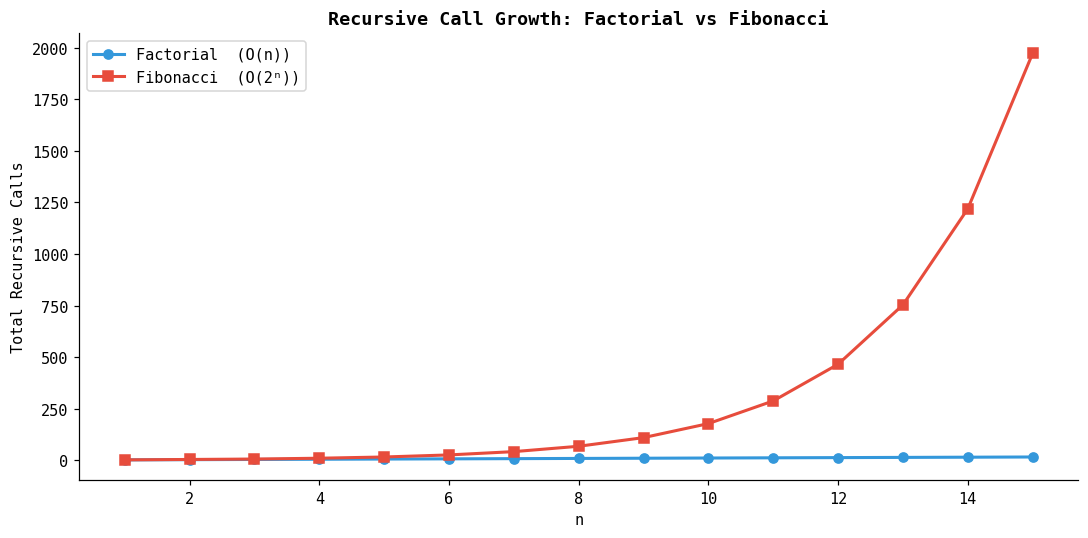

In [22]:
# ── RECURSION CALL GROWTH CHART ───────────────────────────────────────────────

def _fact_c(n): return 1 if n <= 1 else n * _fact_c(n - 1)
def _fib_c(n):  return n if n <= 1 else _fib_c(n-1) + _fib_c(n-2)

ns = list(range(1, 16))

fact_counts, fib_counts = [], []
for n in ns:
    pf = RecursionProfiler(_fact_c); _fact_c = pf; pf(n); fact_counts.append(pf.calls); _fact_c = pf.fn
    pb = RecursionProfiler(_fib_c);  _fib_c  = pb; pb(n); fib_counts.append(pb.calls);  _fib_c  = pb.fn

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ns, fact_counts, 'o-', label='Factorial  (O(n))',       color='#3498db', lw=2)
ax.plot(ns, fib_counts,  's-', label='Fibonacci  (O(2ⁿ))',      color='#e74c3c', lw=2)
ax.set_xlabel('n')
ax.set_ylabel('Total Recursive Calls')
ax.set_title('Recursive Call Growth: Factorial vs Fibonacci', fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('recursion_call_growth.png', bbox_inches='tight')
plt.show()

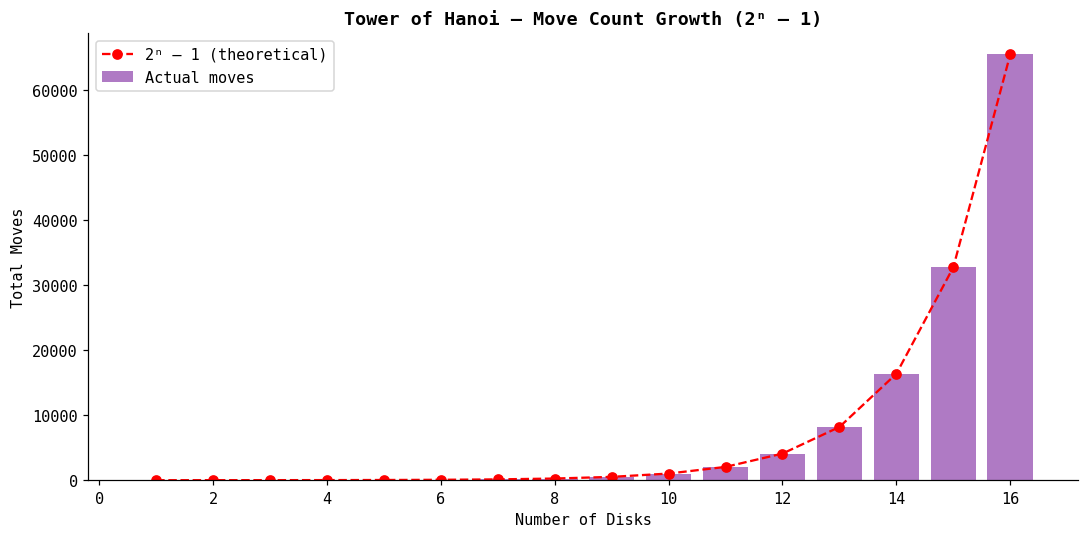

In [23]:
# ── HANOI MOVE COUNT vs DISKS ─────────────────────────────────────────────────
# Demonstrates exponential growth (2^n - 1) visually

def count_hanoi_moves(n):
    moves = []
    def _hanoi(n, s, a, d):
        if n == 1: moves.append(1); return
        _hanoi(n-1, s, d, a)
        moves.append(n)
        _hanoi(n-1, a, s, d)
    _hanoi(n, 'A', 'B', 'C')
    return len(moves)

disk_counts = list(range(1, 17))
move_counts = [count_hanoi_moves(n) for n in disk_counts]
theoretical  = [2**n - 1 for n in disk_counts]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(disk_counts, move_counts, color='#9b59b6', alpha=0.8, label='Actual moves')
ax.plot(disk_counts, theoretical, 'r--o', label='2ⁿ – 1 (theoretical)', lw=1.5)
ax.set_xlabel('Number of Disks')
ax.set_ylabel('Total Moves')
ax.set_title('Tower of Hanoi — Move Count Growth (2ⁿ – 1)', fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('hanoi_growth.png', bbox_inches='tight')
plt.show()

---
## Summary

| Component | What was implemented |
|---|---|
| **Part 1 — Sorting** | All 8 algorithms: Bubble, Selection, Insertion, Merge, Quick, Random-Quick, Counting, Radix |
| | Metrics: time (ms), comparisons, swaps |
| | Charts: benchmark bar chart, scalability line chart, best/avg/worst case pivot |
| | Step-by-step Bubble Sort trace |
| **Part 2 — MST** | Kruskal's with Union-Find (path compression + rank) |
| | Prim's with min-heap |
| | Step-by-step trace for both |
| | Side-by-side NetworkX visualization |
| | Random large-graph stress test |
| **Part 3 — Recursion** | Factorial, Fibonacci (naive + memoized), Tower of Hanoi |
| | Bonus: Binary Search, Merge Sort trace, GCD, Fast Exponentiation |
| | Call profiler measuring depth and total calls |
| | Charts: call growth comparison, Hanoi exponential growth |